# Scope

Goal: Create a model to predict mile pace based on weather conditions and other run features.

In [1]:
# Import libraries

# General
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas.plotting as pplt
import statsmodels.api as sm

# Statistics
from statistics import stdev
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.model_selection import train_test_split

# Predictive modeling
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance

In [2]:
# Import data
activities_all = pd.read_csv('Activities_2022_2025.csv')

## Data Inspection and Cleaning

In [3]:
# Display all columns
pd.set_option('display.max_columns', None)

#View first 5 rows of data
activities_all.head()

,Activity Type,Date,Date.1,Time,RoundedTime,Date-Time,Temp,RelHumidity,Wind,Favorite,Title,Distance,Calories,Time.1,Avg HR,Max HR,Avg Run Cadence,Max Run Cadence,Avg Pace,Best Pace,Total Ascent,Total Descent,Avg Stride Length,Training Stress ScoreÂ®,Steps,Decompression,Best Lap Time,Number of Laps,Moving Time,Elapsed Time,Min Elevation,Max Elevation
0,Running,1/3/22 16:20,2022-01-03,16:20,16:00,2022-01-03-16:00,42.5,26,8.1,False,Lenexa Running,3.01,300,0:29:30,160,174,167,176,9:49,8:26,52,67,0.98,0,"4,990",No,00:02.1,4,0:29:25,0:29:51,952,996
1,Running,1/12/22 16:09,2022-01-12,16:09,16:00,2022-01-12-16:00,47.5,46,8.1,False,Lenexa Running,3.00,276,0:26:18,164,179,165,221,8:46,7:45,72,87,1.11,0,"4,332",No,08:24.1,3,0:26:17,0:26:18,951,997
2,Running,1/25/22 16:50,2022-01-25,16:50,17:00,2022-01-25-17:00,24.2,16,6.5,False,Lenexa Running,3.01,253,0:25:35,156,178,169,177,8:30,8:02,102,97,1.12,0,"4,374",No,00:03.9,4,0:25:32,0:26:03,952,997
3,Running,1/31/22 16:32,2022-01-31,16:32,17:00,2022-01-31-17:00,54.8,44,8.3,False,Lenexa Running,4.01,363,0:36:06,157,180,162,214,9:01,7:50,139,164,1.10,0,"5,956",No,00:02.3,5,0:36:01,0:36:54,951,"1,027"
4,Running,2/9/22 16:33,2022-02-09,16:33,17:00,2022-02-09-17:00,51.6,35,12.0,False,Lenexa Running,4.00,377,0:34:47,166,181,167,177,8:41,7:40,117,112,1.11,0,"5,792",No,00:02.1,5,0:34:46,0:34:47,952,"1,016"


In [4]:
activities_all.columns

Index(['Activity Type', 'Date', 'Date.1', 'Time', 'RoundedTime', 'Date-Time',
       'Temp', 'RelHumidity', 'Wind', 'Favorite', 'Title', 'Distance',
       'Calories', 'Time.1', 'Avg HR', 'Max HR', 'Avg Run Cadence',
       'Max Run Cadence', 'Avg Pace', 'Best Pace', 'Total Ascent',
       'Total Descent', 'Avg Stride Length', 'Training Stress ScoreÂ®',
       'Steps', 'Decompression', 'Best Lap Time', 'Number of Laps',
       'Moving Time', 'Elapsed Time', 'Min Elevation', 'Max Elevation'],
      dtype='object')

In [5]:
# Drop unnecessary columns
activities_all = activities_all[['Activity Type', 'Date.1', 'Temp', 'RelHumidity', 'Wind', 'Title', 'Distance', 'Calories', 'Time', 'Avg HR', 'Max HR', 'Avg Run Cadence', 'Max Run Cadence', 'Avg Pace','Best Pace', 'Total Ascent', 'Total Descent', 'Avg Stride Length', 'Moving Time', 'Elapsed Time', 'Min Elevation', 'Max Elevation']]

In [6]:
# Rename columns
activities_all.columns = ['activity_type', 'date', 'temp', 'humidity', 'wind', 'title', 'distance', 'calories', 'time', 'avg_hr', 'max_hr', 'avg_cadence', 'max_cadence', 'avg_pace', 'best_pace', 'total_ascent', 'total_descent', 'avg_stride', 'moving_time', 'elapsed_time', 'min_elevation', 'max_elevation']

In [7]:
activities_all.head()

,activity_type,date,temp,humidity,wind,title,distance,calories,time,avg_hr,max_hr,avg_cadence,max_cadence,avg_pace,best_pace,total_ascent,total_descent,avg_stride,moving_time,elapsed_time,min_elevation,max_elevation
0,Running,2022-01-03,42.5,26,8.1,Lenexa Running,3.01,300,16:20,160,174,167,176,9:49,8:26,52,67,0.98,0:29:25,0:29:51,952,996
1,Running,2022-01-12,47.5,46,8.1,Lenexa Running,3.00,276,16:09,164,179,165,221,8:46,7:45,72,87,1.11,0:26:17,0:26:18,951,997
2,Running,2022-01-25,24.2,16,6.5,Lenexa Running,3.01,253,16:50,156,178,169,177,8:30,8:02,102,97,1.12,0:25:32,0:26:03,952,997
3,Running,2022-01-31,54.8,44,8.3,Lenexa Running,4.01,363,16:32,157,180,162,214,9:01,7:50,139,164,1.10,0:36:01,0:36:54,951,"1,027"
4,Running,2022-02-09,51.6,35,12.0,Lenexa Running,4.00,377,16:33,166,181,167,177,8:41,7:40,117,112,1.11,0:34:46,0:34:47,952,"1,016"


In [8]:
activities_all.title.unique()

array(['Lenexa Running', 'Running'], dtype=object)

In [9]:
# Add year and month columns
activities_all['year'] = activities_all.date.apply(lambda x: x[:4])
activities_all['month'] = activities_all.date.apply(lambda x: x[5:7])

In [10]:
activities_all.distance.unique()

array([3.01, 3.  , 4.01, 4.  , 6.  , 4.02, 5.  , 3.11, 3.02, 3.1 , 3.12,
       4.03, 3.2 , 4.15, 3.95, 4.08, 4.09, 5.01, 3.42])

In [11]:
activities_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   activity_type  396 non-null    object 
 1   date           396 non-null    object 
 2   temp           396 non-null    float64
 3   humidity       396 non-null    int64  
 4   wind           396 non-null    float64
 5   title          396 non-null    object 
 6   distance       396 non-null    float64
 7   calories       396 non-null    int64  
 8   time           396 non-null    object 
 9   avg_hr         396 non-null    int64  
 10  max_hr         396 non-null    int64  
 11  avg_cadence    396 non-null    int64  
 12  max_cadence    396 non-null    int64  
 13  avg_pace       396 non-null    object 
 14  best_pace      396 non-null    object 
 15  total_ascent   396 non-null    object 
 16  total_descent  396 non-null    int64  
 17  avg_stride     396 non-null    float64
 18  moving_tim

In [12]:
activities_all.describe(include = 'all')

,activity_type,date,temp,humidity,wind,title,distance,calories,time,avg_hr,max_hr,avg_cadence,max_cadence,avg_pace,best_pace,total_ascent,total_descent,avg_stride,moving_time,elapsed_time,min_elevation,max_elevation,year,month
count,396,396,396.000000,396.000000,396.000000,396,396.000000,396.000000,396,396.000000,396.000000,396.000000,396.000000,396,396,396,396.000000,396.000000,396,396,396.000000,396,396,396
unique,1,396,NaN,NaN,NaN,2,NaN,NaN,124,NaN,NaN,NaN,NaN,81,54,114,NaN,NaN,252,268,NaN,24,4,12
top,Running,2022-01-03,NaN,NaN,NaN,Lenexa Running,NaN,NaN,16:19,NaN,NaN,NaN,NaN,8:30,8:02,95,NaN,NaN,0:34:06,0:34:52,NaN,"1,020",2024,10
freq,396,1,NaN,NaN,NaN,389,NaN,NaN,15,NaN,NaN,NaN,NaN,14,26,12,NaN,NaN,7,5,NaN,185,122,44
mean,NaN,NaN,67.032828,51.972222,7.819697,NaN,3.822525,353.303030,NaN,161.507576,176.929293,168.547980,177.989899,NaN,NaN,NaN,110.053030,1.101237,NaN,NaN,950.833333,NaN,NaN,NaN
std,NaN,NaN,15.392917,17.435211,3.689515,NaN,0.527129,53.120633,NaN,3.226856,3.426634,3.875299,9.474277,NaN,NaN,NaN,46.352581,0.021798,NaN,NaN,7.071963,NaN,NaN,NaN
min,NaN,NaN,19.000000,10.000000,0.900000,NaN,3.000000,247.000000,NaN,141.000000,159.000000,149.000000,172.000000,NaN,NaN,NaN,41.000000,0.980000,NaN,NaN,845.000000,NaN,NaN,NaN
25%,NaN,NaN,57.000000,39.000000,5.175000,NaN,4.000000,345.000000,NaN,160.000000,175.000000,167.000000,174.000000,NaN,NaN,NaN,86.000000,1.090000,NaN,NaN,952.000000,NaN,NaN,NaN
50%,NaN,NaN,69.550000,48.000000,7.200000,NaN,4.000000,364.000000,NaN,162.000000,177.000000,169.000000,176.000000,NaN,NaN,NaN,105.500000,1.100000,NaN,NaN,952.000000,NaN,NaN,NaN
75%,NaN,NaN,79.325000,62.000000,10.000000,NaN,4.010000,374.000000,NaN,163.250000,179.000000,171.000000,177.000000,NaN,NaN,NaN,126.000000,1.120000,NaN,NaN,952.000000,NaN,NaN,NaN


In [13]:
activities_reg = activities_all

In [14]:
activities_reg.head()

,activity_type,date,temp,humidity,wind,title,distance,calories,time,avg_hr,max_hr,avg_cadence,max_cadence,avg_pace,best_pace,total_ascent,total_descent,avg_stride,moving_time,elapsed_time,min_elevation,max_elevation,year,month
0,Running,2022-01-03,42.5,26,8.1,Lenexa Running,3.01,300,16:20,160,174,167,176,9:49,8:26,52,67,0.98,0:29:25,0:29:51,952,996,2022,01
1,Running,2022-01-12,47.5,46,8.1,Lenexa Running,3.00,276,16:09,164,179,165,221,8:46,7:45,72,87,1.11,0:26:17,0:26:18,951,997,2022,01
2,Running,2022-01-25,24.2,16,6.5,Lenexa Running,3.01,253,16:50,156,178,169,177,8:30,8:02,102,97,1.12,0:25:32,0:26:03,952,997,2022,01
3,Running,2022-01-31,54.8,44,8.3,Lenexa Running,4.01,363,16:32,157,180,162,214,9:01,7:50,139,164,1.10,0:36:01,0:36:54,951,"1,027",2022,01
4,Running,2022-02-09,51.6,35,12.0,Lenexa Running,4.00,377,16:33,166,181,167,177,8:41,7:40,117,112,1.11,0:34:46,0:34:47,952,"1,016",2022,02


In [15]:
# Remove entries with blank data and remove commas from numerical values
activities_reg = activities_reg[(activities_reg.total_ascent != '--') & (activities_reg.temp != 'NaN') & (activities_reg.humidity != 'NaN') & (activities_reg.wind != 'NaN') & (activities_reg.moving_time != '00:00:00') ]
activities_reg.max_elevation = activities_reg.max_elevation.apply(lambda x: x.replace(',', ''))
activities_reg = activities_reg.reset_index(drop = True)

In [16]:
# Remove entry with invalid elevation info
activities_reg = activities_reg[activities_reg.date!='2023-09-06']

In [17]:
# Update data types
activities_reg.distance = activities_reg.distance.astype('float')

# Columns to change to int
int_list = ['calories', 'avg_hr', 'max_hr', 'avg_cadence', 'max_cadence', 'total_ascent', 'total_descent', 'min_elevation', 'max_elevation', 'temp', 'humidity', 'wind']

for column in int_list:
    activities_reg[column] = activities_reg[column].astype('int')

In [18]:
# Remove data with no heart rate data
activities_reg = activities_reg[(activities_reg.avg_hr != 0.000000) & (activities_reg.max_hr != 0.000000)]

In [19]:
# Add elevation difference column
activities_reg['elev_diff'] = activities_reg.max_elevation - activities_reg.min_elevation

In [20]:
# Get just date from 'date' column
activities_reg.date = pd.to_datetime(activities_reg.date)
activities_reg.date = activities_reg.date.apply(lambda x: x.strftime('%Y-%m-%d'))

# Convert avg_pace to int type
activities_reg['pace_str'] = activities_reg.avg_pace.astype(str)
activities_reg['pace_min'] = activities_reg.pace_str.apply(lambda x: x[0:1] if len(x) == 4 else x[0:2]).astype('int')
activities_reg['pace_sec'] = activities_reg.pace_str.apply(lambda x: x[-2:]).astype('int')
activities_reg['avg_pace_int'] = activities_reg.pace_min + (activities_reg.pace_sec / 60)

activities_reg.head()

,activity_type,date,temp,humidity,wind,title,distance,calories,time,avg_hr,max_hr,avg_cadence,max_cadence,avg_pace,best_pace,total_ascent,total_descent,avg_stride,moving_time,elapsed_time,min_elevation,max_elevation,year,month,elev_diff,pace_str,pace_min,pace_sec,avg_pace_int
0,Running,2022-01-03,42,26,8,Lenexa Running,3.01,300,16:20,160,174,167,176,9:49,8:26,52,67,0.98,0:29:25,0:29:51,952,996,2022,01,44,9:49,9,49,9.816667
1,Running,2022-01-12,47,46,8,Lenexa Running,3.00,276,16:09,164,179,165,221,8:46,7:45,72,87,1.11,0:26:17,0:26:18,951,997,2022,01,46,8:46,8,46,8.766667
2,Running,2022-01-25,24,16,6,Lenexa Running,3.01,253,16:50,156,178,169,177,8:30,8:02,102,97,1.12,0:25:32,0:26:03,952,997,2022,01,45,8:30,8,30,8.500000
3,Running,2022-01-31,54,44,8,Lenexa Running,4.01,363,16:32,157,180,162,214,9:01,7:50,139,164,1.10,0:36:01,0:36:54,951,1027,2022,01,76,9:01,9,1,9.016667
4,Running,2022-02-09,51,35,12,Lenexa Running,4.00,377,16:33,166,181,167,177,8:41,7:40,117,112,1.11,0:34:46,0:34:47,952,1016,2022,02,64,8:41,8,41,8.683333


In [21]:
activities_reg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 395 entries, 0 to 395
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   activity_type  395 non-null    object 
 1   date           395 non-null    object 
 2   temp           395 non-null    int64  
 3   humidity       395 non-null    int64  
 4   wind           395 non-null    int64  
 5   title          395 non-null    object 
 6   distance       395 non-null    float64
 7   calories       395 non-null    int64  
 8   time           395 non-null    object 
 9   avg_hr         395 non-null    int64  
 10  max_hr         395 non-null    int64  
 11  avg_cadence    395 non-null    int64  
 12  max_cadence    395 non-null    int64  
 13  avg_pace       395 non-null    object 
 14  best_pace      395 non-null    object 
 15  total_ascent   395 non-null    int64  
 16  total_descent  395 non-null    int64  
 17  avg_stride     395 non-null    float64
 18  moving_time    

## EDA

In [22]:
activities_reg.describe(include = 'all')

,activity_type,date,temp,humidity,wind,title,distance,calories,time,avg_hr,max_hr,avg_cadence,max_cadence,avg_pace,best_pace,total_ascent,total_descent,avg_stride,moving_time,elapsed_time,min_elevation,max_elevation,year,month,elev_diff,pace_str,pace_min,pace_sec,avg_pace_int
count,395,395,395.000000,395.000000,395.000000,395,395.000000,395.000000,395,395.000000,395.000000,395.000000,395.000000,395,395,395.000000,395.000000,395.000000,395,395,395.000000,395.000000,395,395,395.000000,395,395.000000,395.000000,395.000000
unique,1,395,NaN,NaN,NaN,2,NaN,NaN,123,NaN,NaN,NaN,NaN,81,53,NaN,NaN,NaN,252,267,NaN,NaN,4,12,NaN,81,NaN,NaN,NaN
top,Running,2022-01-03,NaN,NaN,NaN,Lenexa Running,NaN,NaN,16:19,NaN,NaN,NaN,NaN,8:30,8:02,NaN,NaN,NaN,0:34:06,0:34:52,NaN,NaN,2024,10,NaN,8:30,NaN,NaN,NaN
freq,395,1,NaN,NaN,NaN,388,NaN,NaN,15,NaN,NaN,NaN,NaN,14,26,NaN,NaN,NaN,7,5,NaN,NaN,122,44,NaN,14,NaN,NaN,NaN
mean,NaN,NaN,66.551899,51.982278,7.359494,NaN,3.822076,353.298734,NaN,161.518987,176.939241,168.546835,178.000000,NaN,NaN,98.582278,109.650633,1.101291,NaN,NaN,951.101266,1015.260759,NaN,NaN,64.159494,NaN,8.159494,31.189873,8.679325
std,NaN,NaN,15.423932,17.456173,3.702432,NaN,0.527722,53.187933,NaN,3.222938,3.425250,3.880147,9.484157,NaN,NaN,45.414841,45.713569,0.021800,NaN,NaN,4.651824,12.440941,NaN,NaN,12.872170,NaN,0.373459,14.151174,0.332414
min,NaN,NaN,19.000000,10.000000,0.000000,NaN,3.000000,247.000000,NaN,141.000000,159.000000,149.000000,172.000000,NaN,NaN,35.000000,41.000000,0.980000,NaN,NaN,899.000000,982.000000,NaN,NaN,43.000000,NaN,8.000000,0.000000,8.083333
25%,NaN,NaN,56.500000,39.000000,5.000000,NaN,4.000000,344.000000,NaN,160.000000,175.000000,167.000000,174.000000,NaN,NaN,76.000000,86.000000,1.090000,NaN,NaN,952.000000,1015.000000,NaN,NaN,64.000000,NaN,8.000000,22.000000,8.466667
50%,NaN,NaN,69.000000,48.000000,7.000000,NaN,4.000000,364.000000,NaN,162.000000,177.000000,169.000000,176.000000,NaN,NaN,94.000000,105.000000,1.100000,NaN,NaN,952.000000,1020.000000,NaN,NaN,68.000000,NaN,8.000000,32.000000,8.633333
75%,NaN,NaN,79.000000,62.000000,10.000000,NaN,4.010000,374.000000,NaN,163.500000,179.000000,171.000000,177.000000,NaN,NaN,109.000000,125.500000,1.120000,NaN,NaN,952.000000,1020.000000,NaN,NaN,68.000000,NaN,8.000000,41.000000,8.833333


In [23]:
# Export to CSV for Tableau analysis
# activities_reg.to_csv('/Users/macbeth/Documents/Codecademy_Projects/Inference-Final-Project/activities_clean.csv')

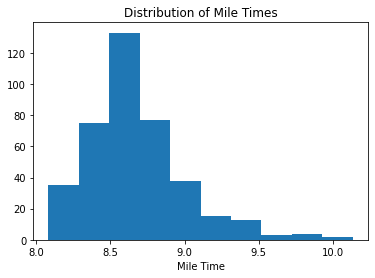

<Figure size 432x288 with 0 Axes>

In [24]:
# Check distribution of average pace values
plt.hist(activities_reg.avg_pace_int)
plt.title('Distribution of Mile Times')
plt.xlabel('Mile Time')
plt.show()
plt.clf()

# Slightly right-skewed

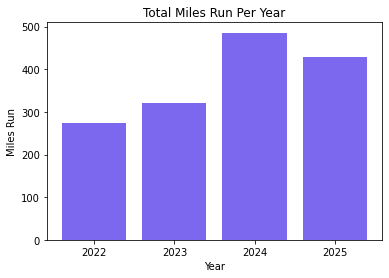

<Figure size 432x288 with 0 Axes>

In [25]:
# Compare total miles run by year
years = activities_reg.year.unique()
years.sort()
miles = [sum(activities_reg.distance[(activities_reg.year == i)]) for i in years]

plt.bar(years, miles, color = 'mediumslateblue')
plt.title('Total Miles Run Per Year')
plt.xlabel('Year')
plt.ylabel('Miles Run')
plt.show()
plt.clf()

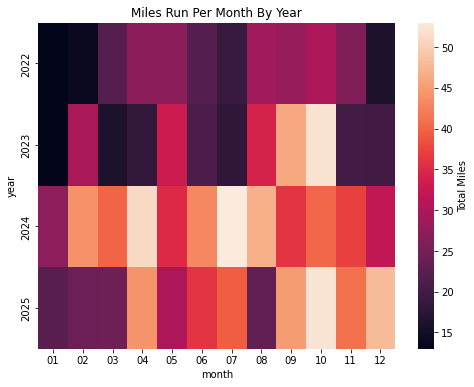

<Figure size 432x288 with 0 Axes>

In [26]:
# Heatmap of miles per month
totals = activities_reg.groupby(['year', 'month']).sum()
totals_mnth_yr = totals.reset_index().pivot(index = 'year', columns = 'month', values = 'distance')

plt.figure(figsize = (8, 6))

sns.heatmap(totals_mnth_yr, cbar_kws = {'label': 'Total Miles'})
plt.title('Miles Run Per Month By Year')
plt.show()
plt.clf()

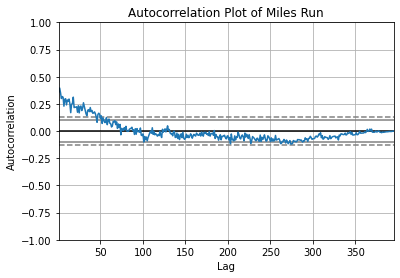

<Figure size 432x288 with 0 Axes>

In [27]:
pplt.autocorrelation_plot(activities_reg.distance)
plt.title('Autocorrelation Plot of Miles Run')
plt.show()
plt.clf()

There does not appear to be seasonality, and the observations appear to be independent of each other. The distance on one day does not appear to be an indication of the distance run on the next.

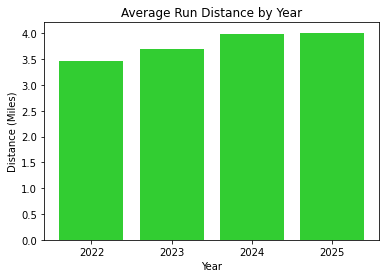

<Figure size 432x288 with 0 Axes>

In [28]:
# Plot average run distance by year
years = activities_reg.year.unique()
years.sort()
avg_dist = [(activities_reg.distance[activities_reg.year == i]).mean() for i in years]

plt.bar(years, avg_dist, color = 'limegreen')
plt.title('Average Run Distance by Year')
plt.xlabel('Year')
plt.ylabel('Distance (Miles)')
plt.show()
plt.clf()

From 2022 to 2025, my average run distance has increased by about half a mile.

# Analysis

## Goal: Predict average mile pace based on run features

Method: I will create and test various regression models to predict the average mile pace of my runs.

In [29]:
# Limit features to factors external to the run
# Target is average mile pace
feature_list = ['distance', 'temp', 'humidity', 'wind', 'month']
X = activities_reg[feature_list]

y = activities_reg['avg_pace_int']

In [30]:
# Change data type of month feature to int
X = X.astype({'month': int})

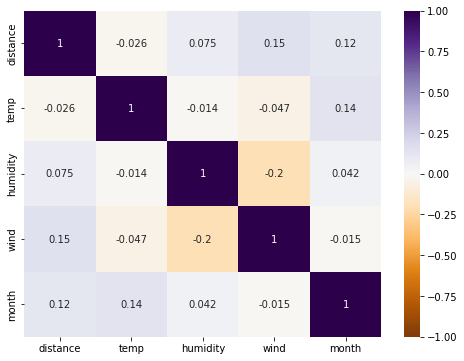

<Figure size 432x288 with 0 Axes>

In [31]:
# Check for multicollinearity
corr_grid = X.corr()

plt.figure(figsize = (8,6))
sns.heatmap(corr_grid, xticklabels=corr_grid.columns, yticklabels=corr_grid.columns, vmin=-1, center=0, vmax=1, cmap='PuOr', annot=True)
plt.show()
plt.clf()

In [32]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### Linear Regression

In [33]:
# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict target
y_pred_lin = lr_model.predict(X_train)

# Evaluate model performance on training data
print('Linear Regression Model Training Performance')
print('Bias:', lr_model.intercept_)
print('Coefficients:', lr_model.coef_)
print('Score:', lr_model.score(X_train, y_train))
print('MAE:', mean_absolute_error(y_train, y_pred_lin))
print('RMSE:', np.sqrt(mean_squared_error(y_train, y_pred_lin)))
print('MSE:', mean_squared_error(y_train, y_pred_lin))
print('R^2:', r2_score(y_train, y_pred_lin))
print()

# Evaluate model performance on test data
y_test_pred_lin = lr_model.predict(X_test)

print('Linear Regression Model Test Performance')
print('MAE:', mean_absolute_error(y_test, y_test_pred_lin))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred_lin)))
print('MSE:', mean_squared_error(y_test, y_test_pred_lin))
print('R^2:', r2_score(y_test, y_test_pred_lin))

Linear Regression Model Training Performance
Bias: 8.145357236645511
Coefficients: [ 0.00783328  0.0080216   0.00106614  0.00907716 -0.02389231]
Score: 0.1734514370037641
MAE: 0.22275939241157044
RMSE: 0.30002183511020253
MSE: 0.09001310154289356
R^2: 0.1734514370037641

Linear Regression Model Test Performance
MAE: 0.21663636823974566
RMSE: 0.2998422685487738
MSE: 0.089905386008475
R^2: 0.21643873716639261


### Linear Regression with Polynomial Features

In [34]:
# Create polynomial features object from unscaled data
poly_feat = PolynomialFeatures(degree = 2, include_bias = False)
pipe_scale = StandardScaler()
lr_pipe = LinearRegression()

stages = [('poly_feat', poly_feat),
          ('pipe_scale', pipe_scale),
          ('lr_pipe', lr_pipe)]

# Create and fit pipeline
pipe = Pipeline(stages)
pipe.fit(X_train.values, y_train.values)

# Predict target values
y_train_pred = pipe.predict(X_train.values)

# Evaluate performance on training data
print('Polynomial Model Train Performance')
print('Bias:', pipe.predict([[0, 0, 0, 0, 0]]))
print('Score:', pipe.score(X_train.values, y_train.values))
print('MAE:', mean_absolute_error(y_train.values, y_train_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_train.values, y_train_pred)))
print('MSE:', mean_squared_error(y_train.values, y_train_pred))
print('R^2:', r2_score(y_train.values, y_train_pred))
print()

# Evaluate performance on test data
y_test_pred2 = pipe.predict(X_test.values)

print('Polynomial Model Test Performance')
print('MAE:', mean_absolute_error(y_test.values, y_test_pred2))
print('RMSE:', np.sqrt(mean_squared_error(y_test.values, y_test_pred2)))
print('MSE:', mean_squared_error(y_test.values, y_test_pred2))
print('R^2:', r2_score(y_test.values, y_test_pred2))

Polynomial Model Train Performance
Bias: [10.54865865]
Score: 0.37129811222567877
MAE: 0.19671454449085746
RMSE: 0.2616622416976065
MSE: 0.06846712873021663
R^2: 0.37129811222567877

Polynomial Model Test Performance
MAE: 0.21104499834524
RMSE: 0.2920517024550798
MSE: 0.08529419690691047
R^2: 0.2566270875645087


### Support Vector Regression Model

In [35]:
# Create SVR model
svr = SVR(kernel = 'rbf', C = 0.1)
svr_scale = StandardScaler()

# Create and fit pipeline
steps2 = [('svr_scale', svr_scale),
          ('svr', svr)]
pipe_svr = Pipeline(steps2)
pipe_svr.fit(X_train.values, y_train.values)

# Predict target values
y_pred_svr = pipe_svr.predict(X_train.values)

# Evaluate performance on training data
print('SVR Model Train Performance')
print('Bias:', pipe_svr.predict([[0, 0, 0, 0, 0]]))
print('Score:', pipe_svr.score(X_train.values, y_train.values))
print('MAE:', mean_absolute_error(y_train.values, y_pred_svr))
print('RMSE:', np.sqrt(mean_squared_error(y_train.values, y_pred_svr)))
print('MSE:', mean_squared_error(y_train.values, y_pred_svr))
print('R^2:', r2_score(y_train.values, y_pred_svr))
print()

# Evaluate performance on test data
y_test_svr = pipe_svr.predict(X_test.values)

print('SVR Model Test Performance')
print('MAE:', mean_absolute_error(y_test.values, y_test_svr))
print('RMSE:', np.sqrt(mean_squared_error(y_test.values, y_test_svr)))
print('MSE:', mean_squared_error(y_test.values, y_test_svr))
print('R^2:', r2_score(y_test.values, y_test_svr))

SVR Model Train Performance
Bias: [8.69197343]
Score: 0.2962468709247186
MAE: 0.19153868644799588
RMSE: 0.2768400028044214
MSE: 0.07664038715275205
R^2: 0.2962468709247186

SVR Model Test Performance
MAE: 0.20947185791316839
RMSE: 0.3018312627332867
MSE: 0.09110211116317035
R^2: 0.20600880059519056


### Decision Tree Regression

In [36]:
# Create and train model
tree_scale = StandardScaler()
tree = DecisionTreeRegressor(max_depth = 3, random_state = 42)

steps3 = [('tree_scale', tree_scale),
          ('tree', tree)]

pipe_tree = Pipeline(steps3)
pipe_tree.fit(X_train.values, y_train.values)

# Predict target values
y_pred_tree = pipe_tree.predict(X_train.values)

# Evaluate performance on training data
print('Decision Tree Model Train Performance')
print('Bias:', pipe_tree.predict([[0, 0, 0, 0, 0]]))
print('Score:', pipe_tree.score(X_train.values, y_train.values))
print('MAE:', mean_absolute_error(y_train.values, y_pred_tree))
print('RMSE:', np.sqrt(mean_squared_error(y_train.values, y_pred_tree)))
print('MSE:', mean_squared_error(y_train.values, y_pred_tree))
print('R^2:', r2_score(y_train.values, y_pred_tree))
print()

# Evaluate performance on test data
y_test_tree = pipe_tree.predict(X_test.values)

print('Decision Tree Model Test Performance')
print('MAE:', mean_absolute_error(y_test.values, y_test_tree))
print('RMSE:', np.sqrt(mean_squared_error(y_test.values, y_test_tree)))
print('MSE:', mean_squared_error(y_test.values, y_test_tree))
print('R^2:', r2_score(y_test.values, y_test_tree))

Decision Tree Model Train Performance
Bias: [9.56666667]
Score: 0.4310818412879108
MAE: 0.19234154628453357
RMSE: 0.24891070417008287
MSE: 0.061956538650446515
R^2: 0.4310818412879108

Decision Tree Model Test Performance
MAE: 0.21687514224471474
RMSE: 0.29066492444310976
MSE: 0.0844860983015187
R^2: 0.26366998890609417


### Artificial Neural Net Model

In [37]:
# Build and train model
ann_scale = StandardScaler()
ann = MLPRegressor(hidden_layer_sizes = (50, 25, 10),
                   solver='sgd', 
                   max_iter = 400,
                  random_state = 42)

steps3 = [('ann_scale', ann_scale),
          ('ann', ann)]

pipe_ann = Pipeline(steps3)
pipe_ann.fit(X_train.values, y_train.values)

# Predict target values
y_pred_ann = pipe_ann.predict(X_train.values)

# Evaluate performance on training data
print('ANN Model Train Performance')
print('Bias:', pipe_ann.predict([[0, 0, 0, 0, 0]]))
print('Score:', pipe_ann.score(X_train.values, y_train.values))
print('MAE:', mean_absolute_error(y_train.values, y_pred_ann))
print('RMSE:', np.sqrt(mean_squared_error(y_train.values, y_pred_ann)))
print('MSE:', mean_squared_error(y_train.values, y_pred_ann))
print('R^2:', r2_score(y_train.values, y_pred_ann))
print()

# Evaluate performance on test data
y_test_ann = pipe_ann.predict(X_test.values)

print('Ann Model Test Performance')
print('MAE:', mean_absolute_error(y_test.values, y_test_ann))
print('RMSE:', np.sqrt(mean_squared_error(y_test.values, y_test_ann)))
print('MSE:', mean_squared_error(y_test.values, y_test_ann))
print('R^2:', r2_score(y_test.values, y_test_ann))

ANN Model Train Performance
Bias: [10.46553817]
Score: 0.22756539934878417
MAE: 0.2235117895395988
RMSE: 0.2900344161029601
MSE: 0.084119962524185
R^2: 0.22756539934878417

Ann Model Test Performance
MAE: 0.2581244293208732
RMSE: 0.32802372490767107
MSE: 0.10759956410230345
R^2: 0.06222692464276891


### Comparison of Results

| Model | Set | RMSE | R2 |
|:---|:---|:---|:---|
|Linear Regression|Training|0.35|32.53|
||Test|0.33|39.52|
|Polynomial|Training|0.31|45.94|
||Test|0.33|40.96|
|SVR|Training|0.33|39.58|
||Test|0.32|43.60|
|Decision Tree|Training|0.32|41.49|
||Test|0.40|12.22|
|Artificial Neural Network|Training|0.32|44.11|
||Test|0.38|20.46|

The SVR model has the most consistent performance between the train and test data.

### Hyperparameter Tuning

In [38]:
X_scale = svr_scale.fit_transform(X)

svr2 = SVR()

param_grid = [
    {'C': [0.01, 0.1, 0.5, 1.0],
    'epsilon': [0.01, 0.1, 0.5, 1.0]}
]

grid_search = GridSearchCV(svr2, param_grid, cv = 3, scoring = 'r2')
grid_search.fit(X_scale, y)

best_params = grid_search.best_params_
print(best_params)

{'C': 0.01, 'epsilon': 0.1}


In [39]:
best_c = grid_search.best_params_['C']
best_epsilon = grid_search.best_params_['epsilon']

### Final Model

In [40]:
# Final SVR model
best_svr = SVR(C = best_c, epsilon = best_epsilon)
svr_scaler = StandardScaler()

steps_final = [('svr_scaler', svr_scaler),
              ('best_svr', best_svr)]

final_model = Pipeline(steps_final)
final_model.fit(X_train.values, y_train.values)

y_pred_final = final_model.predict(X_train.values)

print('Final SVR Model Training Performance')
print('R^2:', r2_score(y_train.values, y_pred_final))
print()

y_pred_test_final = final_model.predict(X_test.values)

print('Final SVR Model Test Performance')
print('R^2:', r2_score(y_test.values, y_pred_test_final))

Final SVR Model Training Performance
R^2: 0.09533167463090386

Final SVR Model Test Performance
R^2: 0.06700556174963257


Feature: 0, Score: 0.00175
Feature: 1, Score: 0.01121
Feature: 2, Score: 0.00124
Feature: 3, Score: 0.00088
Feature: 4, Score: 0.00501


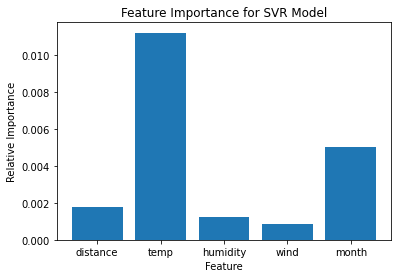

In [41]:
# Perform permutation importance
results = permutation_importance(final_model, X.values, y.values, scoring='neg_mean_squared_error')

# Get importance
importance = results.importances_mean

# Summarize feature importance
for i,v in enumerate(importance):
    print('Feature: %0d, Score: %.5f' % (i,v))
    
# Plot feature importance
plt.bar(feature_list, importance)
plt.title('Feature Importance for SVR Model')
plt.xlabel('Feature')
plt.ylabel('Relative Importance')
plt.show()

In [42]:
# Export importance to CSV for Tableau analysis
# importance_df = pd.DataFrame(importance, columns = ['importance'], index = feature_list)
# importance_df
# importance_df.to_csv('/Users/macbeth/Documents/Codecademy_Projects/Inference-Final-Project/importance.csv')

In [43]:
# Calculate fitted values and residuals
fitted_values = pipe_svr.predict(X)
residuals = y - fitted_values

In [44]:
# Export residuals and fitted values to CSV for Tableau analysis
# res_fit_dict = {'fitted_values': fitted_values, 'residuals': residuals}
# res_fit_df = pd.DataFrame(res_fit_dict)
# res_fit_df.to_csv('/Users/macbeth/Documents/Codecademy_Projects/Inference-Final-Project/res_fit_data.csv')

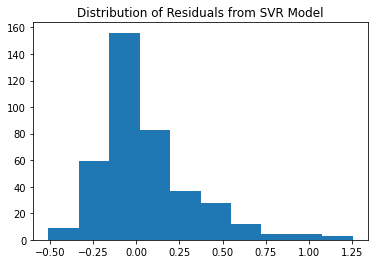

<Figure size 432x288 with 0 Axes>

In [45]:
# Check normality assumption
plt.hist(residuals)
plt.title('Distribution of Residuals from SVR Model')
plt.show()
plt.clf()

The residuals are slightly right-skewed

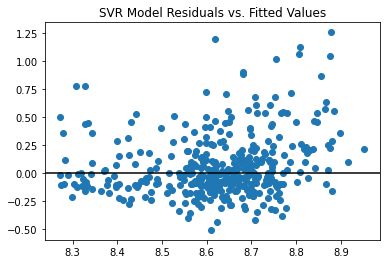

<Figure size 432x288 with 0 Axes>

In [46]:
# Check homoscedasticity assumption
plt.scatter(fitted_values, residuals)
plt.axhline(y=0, color='black', linestyle='-')
plt.title('SVR Model Residuals vs. Fitted Values')
plt.show()
plt.clf()

There is a relatively even distribution of residuals vs fitted values, indicating homoscedasticity.

# Conclusions

The best model I was able to make was a support vector regression model. Surprisingly, the wind speed had the lowest impact on the average mile pace. This could be because I'm less likely to run when the wind is stronger. The temperature had the highest impact on my pace.
This model only accounts for about 40% of the variation in my average mile pace. Because this is heavily dependent on things that are harder to measure, like how tired/energized I am, how much I've been training, and how much other activity I've been doing, I think this is a reasonable level with the information I have available.

## Other Observations

The distribution of my mile paces is normal, but slightly right-skewed (skewed towards slower times).

My total run distance by year (Jan-Sept) was pretty consistent for 2017-2019, then dropped to a lower, but still consistent level for 2020-2022. This makes sense, because I was using training schedules in 2017-2019, which leads me to run farther. This is also demonstrated in the heatmap of miles per month, where I ran more miles in the summers of those years than any other times in this dataset.

In [47]:
from watermark import watermark
print(watermark())

Last updated: 2026-03-27T14:25:59.533368-05:00

Python implementation: CPython
Python version       : 3.9.12
IPython version      : 8.2.0

Compiler    : Clang 12.0.0 
OS          : Darwin
Release     : 25.3.0
Machine     : x86_64
Processor   : i386
CPU cores   : 8
Architecture: 64bit

